In [1]:
!pip install d2l==0.17.0
!pip install tensorflow  
import tensorflow as tf
from d2l import tensorflow as d2l
import matplotlib.pyplot as plt
import numpy as np
import time

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)


In [6]:
def simplified_alexnet_224():
    return tf.keras.models.Sequential([
        # Минимальный сверточный блок
        tf.keras.layers.Conv2D(16, 5, strides=2, activation='relu'),
        tf.keras.layers.MaxPool2D(2),

        # Еще один простой слой
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(2),

        # Финальные слои - минимальные
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

def alexnet_28x28():
    return tf.keras.models.Sequential([
        # Всего 2 сверточных слоя для 28x28
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(2),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(2),

        # Минимальные полносвязные слои
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

# Функция для проверки размерностей
def check_output_shapes(model, input_shape):
    X = tf.random.uniform(input_shape)
    print("Проверка размерностей выходов слоев:")
    for layer in model.layers:
        X = layer(X)
        print(f"{layer.__class__.__name__:20} output shape: {X.shape}")



loss 0.349, train acc 0.874, test acc 0.862
1412.0 examples/sec on /CPU:0


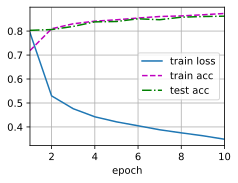

In [7]:
# Функция для обучения и оценки модели
def train_and_evaluate(model, batch_size, resize=None, model_name=""):
    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print(f"Batch size: {batch_size}, Resize: {resize}")
    print(f"{'='*50}")

    # Загрузка данных
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=resize)

    # Обучение модели
    lr, num_epochs = 0.01, 10
    d2l.train_ch6(model, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

    return model
print("Упрощенная AlexNet для 224x224")
model1 = simplified_alexnet_224()
model1.build((None, 224, 224, 1))
print("Архитектура модели:")
model1.summary()

check_output_shapes(model1, (1, 224, 224, 1))
trained_model1 = train_and_evaluate(simplified_alexnet_224, batch_size=128, resize=224, model_name="Упрощенная AlexNet 224x224")


loss 0.478, train acc 0.823, test acc 0.812
16344.4 examples/sec on /CPU:0


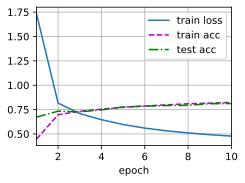

In [8]:
print("\n AlexNet адаптированная для 28x28")
model2 = alexnet_28x28()
model2.build((None, 28, 28, 1))
print("Архитектура модели:")
model2.summary()

check_output_shapes(model2, (1, 28, 28, 1))
trained_model2 = train_and_evaluate(alexnet_28x28, batch_size=128, resize=None, model_name="AlexNet 28x28")

loss 0.725, train acc 0.733, test acc 0.730
20550.1 examples/sec on /CPU:0
Использование памяти GPU после обучения:
memory.used [MiB]
19 MiB


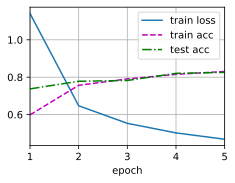

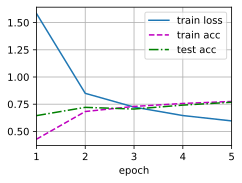

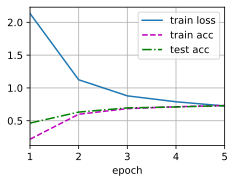

In [9]:
# Задание 3 - Исправленная версия
print("\n Влияние размера пакета на производительность")
batch_sizes = [64, 128, 256]

# Исправленная функция для AlexNet 28x28 с указанием input_shape
def alexnet_28x28_fixed():
    return tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPool2D(2),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

for batch_size in batch_sizes:
    print(f"\nТестирование с batch_size = {batch_size}")
    
    # Мониторинг использования памяти
    print("Попытка использование памяти GPU до обучения:")
    get_ipython().system('nvidia-smi --query-gpu=memory.used --format=csv')
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=None)
    
    lr, num_epochs = 0.01, 5
    # Передаем функцию
    d2l.train_ch6(alexnet_28x28_fixed, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())
    
    print("Использование памяти GPU после обучения:")
    get_ipython().system('nvidia-smi --query-gpu=memory.used --format=csv')